<a href="https://colab.research.google.com/github/vanecornejo/Procesos-Estocasticos/blob/main/Matriz%20fundamental.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Matriz fundamental**

## *Serpientes y Escaleras*

El juego de serpientes y escaleras puede modelarse como una cadena de Markov donde se analiza un tablero con casillas del 1 al 20 y se lanza un dado justo (valores de 1 a 6).

- Cada casilla representa un estado
- Las transiciones dependen del dado
- Existe un estado absorbente (meta)
- Algunas casillas tienen saltos (serpientes o escaleras):

Escaleras:
  - 3 → 11
  - 15 → 19

Serpientes:
  - 17 → 9
  - 13 → 5

y el estado absorbente es en la casilla 20 donde $E[20]=0$.

---

Se utilizará la matriz fundamental:

$$ N = (I - Q)^{-1} $$

donde:
- Q: matriz de estados transientes
- N: número esperado de visitas


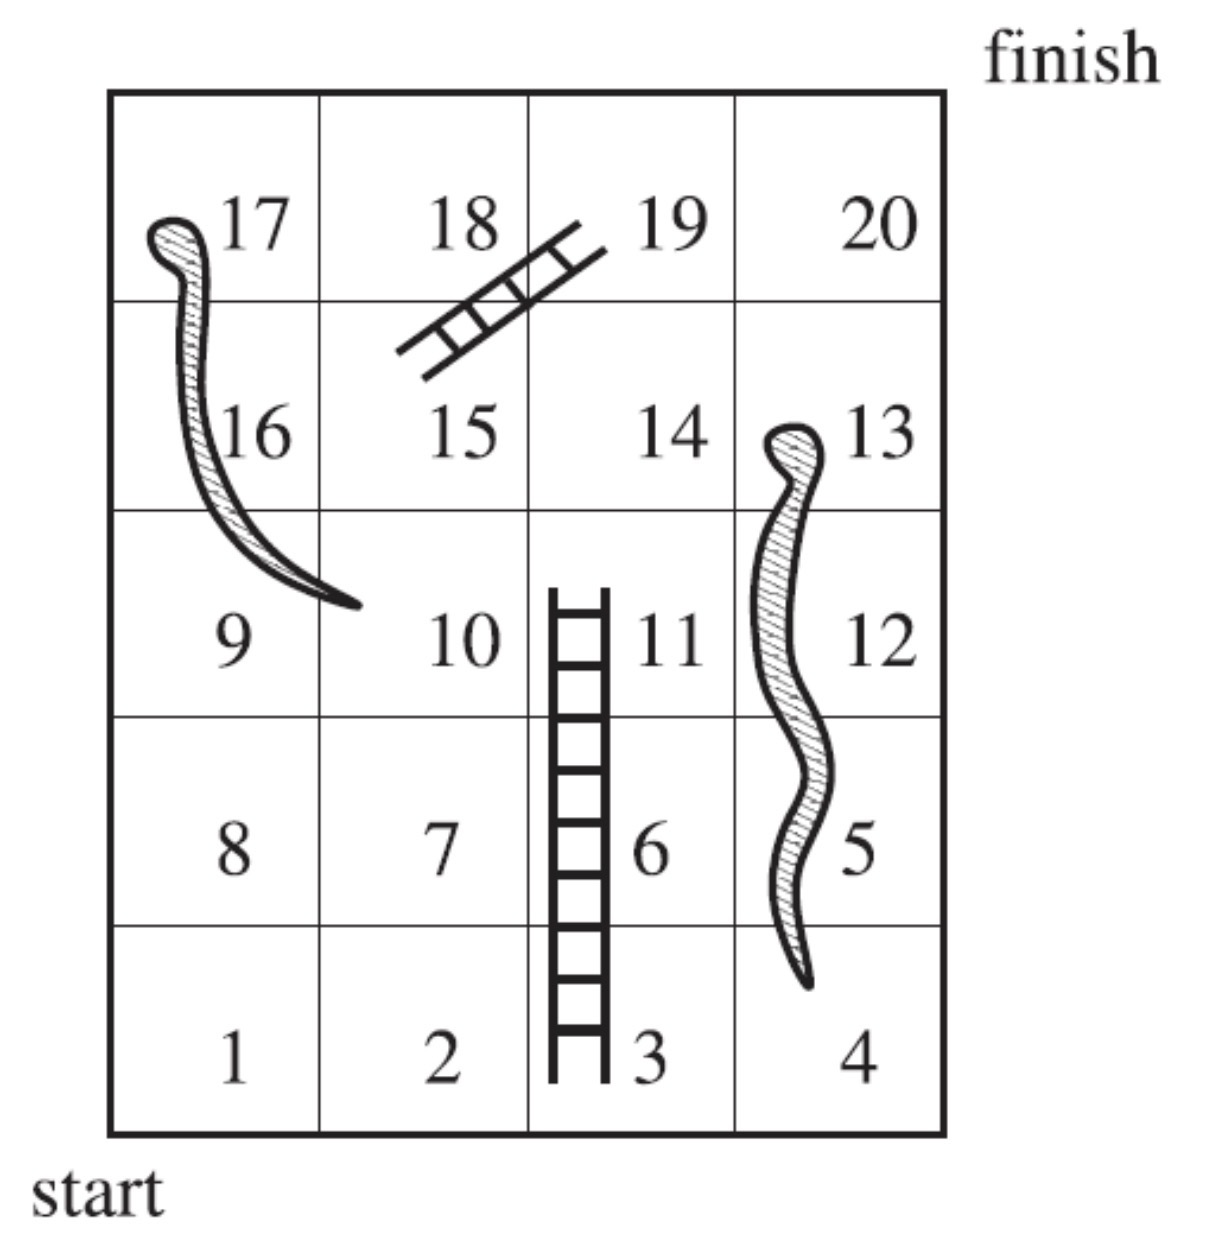

Primero, hacemos la construcción de la matriz de transición.

Se construye una matriz $P$ donde:

$$ P[i,j] = \text{Probabilidad de ir de i a j} $$

In [53]:
import numpy as np
import sympy as sp

In [54]:
n = 20  # número de casillas

# Creamos matriz de ceros de 20 x 20:
P = sp.zeros(n, n)

# Movimientos "especiales" de subir escaleras o bajar serpientes
mov = {3:11, 15:19, 17:9, 13:5}

In [55]:
# Construimos la matriz
for i in range(n):

    # Si estamos en la casilla final (estado absorbente)
    if i == 19:
        P[i,i] = 1  # se queda ahí con probabilidad 1

    else:
        # Simulación de los posibles resultados del dado
        for d in range(1,7):
            j = i + d  # avanza d pasos

            # Si se pasa del final, se queda en la meta
            if j >= 20:
                j = 19

            # Aplica serpiente o escalera si existe
            j = mov.get(j+1, j+1) - 1

            # Suma probabilidad
            P[i,j] += sp.Rational(1,6)

# La imprimimos:
P

Matrix([
[0, 1/6, 0, 1/6, 1/6, 1/6, 1/6,   0,   0,   0, 1/6,   0, 0,   0, 0,   0, 0,   0,   0,   0],
[0,   0, 0, 1/6, 1/6, 1/6, 1/6, 1/6,   0,   0, 1/6,   0, 0,   0, 0,   0, 0,   0,   0,   0],
[0,   0, 0, 1/6, 1/6, 1/6, 1/6, 1/6, 1/6,   0,   0,   0, 0,   0, 0,   0, 0,   0,   0,   0],
[0,   0, 0,   0, 1/6, 1/6, 1/6, 1/6, 1/6, 1/6,   0,   0, 0,   0, 0,   0, 0,   0,   0,   0],
[0,   0, 0,   0,   0, 1/6, 1/6, 1/6, 1/6, 1/6, 1/6,   0, 0,   0, 0,   0, 0,   0,   0,   0],
[0,   0, 0,   0,   0,   0, 1/6, 1/6, 1/6, 1/6, 1/6, 1/6, 0,   0, 0,   0, 0,   0,   0,   0],
[0,   0, 0,   0, 1/6,   0,   0, 1/6, 1/6, 1/6, 1/6, 1/6, 0,   0, 0,   0, 0,   0,   0,   0],
[0,   0, 0,   0, 1/6,   0,   0,   0, 1/6, 1/6, 1/6, 1/6, 0, 1/6, 0,   0, 0,   0,   0,   0],
[0,   0, 0,   0, 1/6,   0,   0,   0,   0, 1/6, 1/6, 1/6, 0, 1/6, 0,   0, 0,   0, 1/6,   0],
[0,   0, 0,   0, 1/6,   0,   0,   0,   0,   0, 1/6, 1/6, 0, 1/6, 0, 1/6, 0,   0, 1/6,   0],
[0,   0, 0,   0, 1/6,   0,   0,   0, 1/6,   0,   0, 1/6, 0, 1/6, 0, 1/6

Ahora, la matriz fundamental se separa en:

- $Q$: estados transientes
- $R$: estados absorbentes

La matriz fundamental es:

$$ N = (I - Q)^{-1} $$

El número esperado de pasos es:

$$ t = N \cdot 1 $$

In [56]:
# Para Q:
Q = P[:19, :19]

# Matriz identidad
I = sp.eye(19)

# Matriz fundamental:
N = (I - Q).inv()

N

Matrix([
[1, 1/6, 0, 7/36, 151185923/212202756, 12222707/35367126, 85558949/212202756, 386709887/1273216536, 815236159/1273216536, 91944517/212202756, 141653309/212202756, 98802893/212202756, 0, 44393755/106101378, 0, 421188229/1273216536, 0, 1546730647/7639299216, 27324403579/45835795296],
[0,   1, 0,  1/6,   24265157/35367126,   1820189/5894521,  12741323/35367126,   89189261/212202756,  134638549/212202756,  15187795/35367126,   22631195/35367126,  16464347/35367126, 0,   7632331/17683563, 0,   69547999/212202756, 0,  259922053/1273216536,   4538297137/7639299216],
[0,   0, 1,  1/6,   24537317/35367126,   1827749/5894521,  12794243/35367126,   89559701/212202756,  165570613/212202756,  16119049/35367126,   17823137/35367126,  16704107/35367126, 0,   7764001/17683563, 0,   66174295/212202756, 0,  259566949/1273216536,   4591319089/7639299216],
[0,   0, 0,    1,     3840995/5894521,   1622586/5894521,    1893017/5894521,    13251119/35367126,    25424875/35367126,    3282853/5894521, 

In [57]:
# El tiempo esperado:

uno = sp.ones(19, 1) # Vector de unos

t = N * uno  # Multiplicación de las matrices

tiradas = t[0]

print("El número promedio de tiradas necesarias es: ", float(tiradas))

El número promedio de tiradas necesarias es:  6.880635705704065


Así, obtuvimos un resultado analítico exacto basado en teoría de Markov.

Veamos y comprobemos el resultado haciendo una simulación del juego.

In [58]:
import random

def juego():
    pos = 0
    tiros = 0

    while pos != 19:
        d = random.randint(1,6)
        pos += d

        if pos >= 20:
            pos = 19

        pos = mov.get(pos+1, pos+1) - 1

        tiros += 1

    return tiros

simulacion_tiradas = [juego() for _ in range(10000)]

print("Promedio simulado:", np.mean(simulacion_tiradas))

Promedio simulado: 6.8873


El número esperado de tiradas para finalizar el juego es aproximadamente 6.

## *Caminata del ratón*

Se modela el sistema con:

- Estado 7: comida (absorbente)
- Estado 8: shock (absorbente)

Vamos a calcular la probabilidad de que el ratón llegue a la comida iniciando por el estado inicial 0 y validar el resultado mediante simulación.

Se busca:

$$ P(\text{llegar a comida} | \text{inicio en 0}) $$

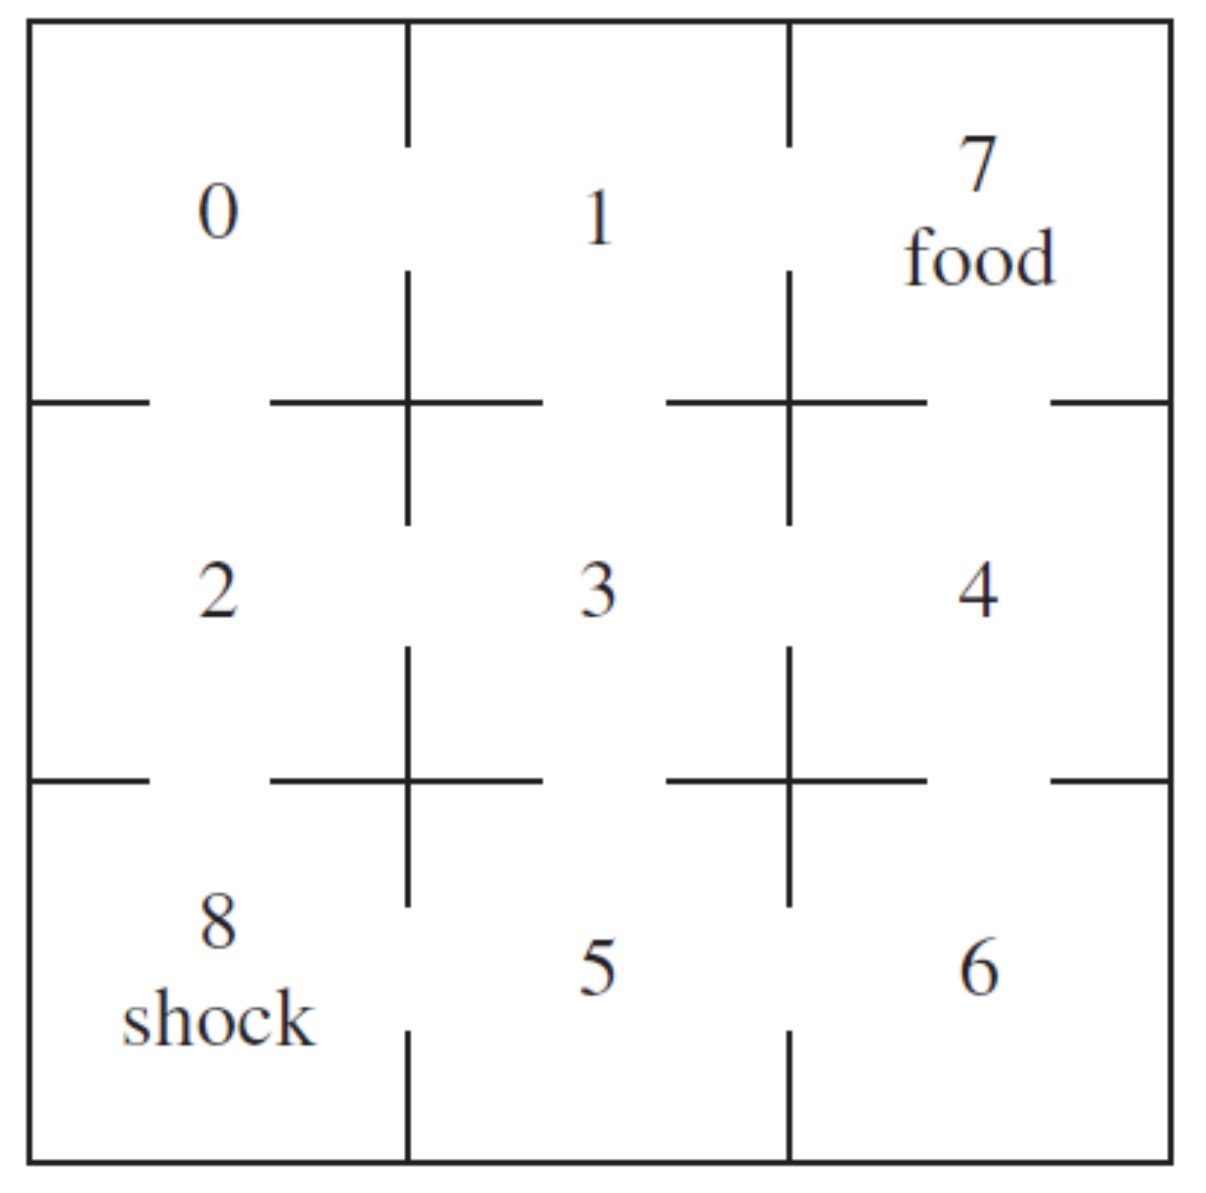

In [59]:
# Creamo una matriz de 9x9
P2 = sp.zeros(9,9)

# Estados absorbentes
P2[7,7] = 1
P2[8,8] = 1

# Definir conexiones del grafo
trans = {
    0:[1,2],
    1:[0,3,7],
    2:[0,3,8],
    3:[1,2,4,5],
    4:[3,6,7],
    5:[3,6,8],
    6:[4,5]
}

# Llenar matriz con probabilidades iguales
for i, vecinos in trans.items():
    for v in vecinos:
        P2[i,v] = sp.Rational(1, len(vecinos))

P2

Matrix([
[  0, 1/2, 1/2,   0,   0,   0,   0,   0,   0],
[1/3,   0,   0, 1/3,   0,   0,   0, 1/3,   0],
[1/3,   0,   0, 1/3,   0,   0,   0,   0, 1/3],
[  0, 1/4, 1/4,   0, 1/4, 1/4,   0,   0,   0],
[  0,   0,   0, 1/3,   0,   0, 1/3, 1/3,   0],
[  0,   0,   0, 1/3,   0,   0, 1/3,   0, 1/3],
[  0,   0,   0,   0, 1/2, 1/2,   0,   0,   0],
[  0,   0,   0,   0,   0,   0,   0,   1,   0],
[  0,   0,   0,   0,   0,   0,   0,   0,   1]])

*Analíticamente:*

In [60]:
# Submatriz de estados transientes
Q2 = P2[:7,:7]

# Submatriz de absorción
R2 = P2[:7,7:]

# Matriz fundamental
N2 = (sp.eye(7) - Q2).inv()

# Probabilidades de absorción
B = N2 * R2

comida = B[0,0]

# Probabilidad de llegar a comida desde estado 0
print("La probabilidad de que el ratón alcance la comida es: ", float(comida))

La probabilidad de que el ratón alcance la comida es:  0.5


Hacemos ahora la simulación para comparar con el resultado en la solución analítica.

In [61]:
def raton():
    pos = 0
    while pos not in [7,8]:
        pos = random.choice(trans[pos])
    return pos

res = [raton() for _ in range(10000)]

print("Probabilidad simulada:", res.count(7)/len(res))


Probabilidad simulada: 0.4986


Comparando el enfoque analítico y la simulacipon, la probabilidad de que el ratón, iniciando  en la casilla 0, alcance la comida es de aproximadamente 0.5.

---

De esta forma, podemos concluir que la matriz fundamental permite obtener resultados exactos y la simulación valida y comprueba los resultados teóricos.